import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

load data set


In [5]:
df = pd.read_csv("/content/House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


**Explore Dataset**

In [6]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(2000, 10)
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


**Check Missing Values**

In [7]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


**data** **cleaning**

In [9]:
df = df.dropna()

**Data Visualization**

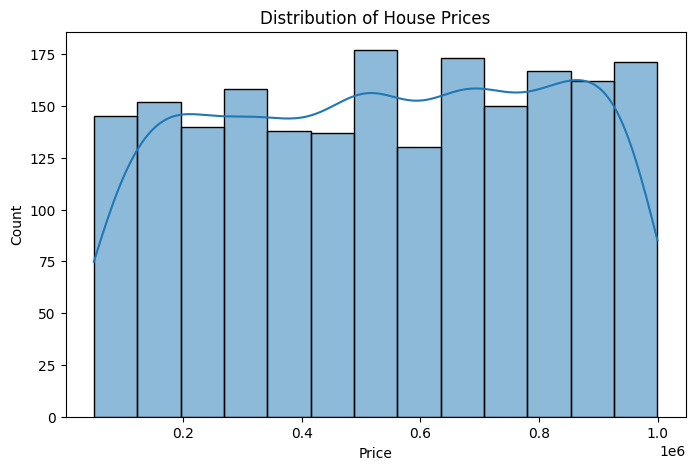

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

**Correlation Heatmap**

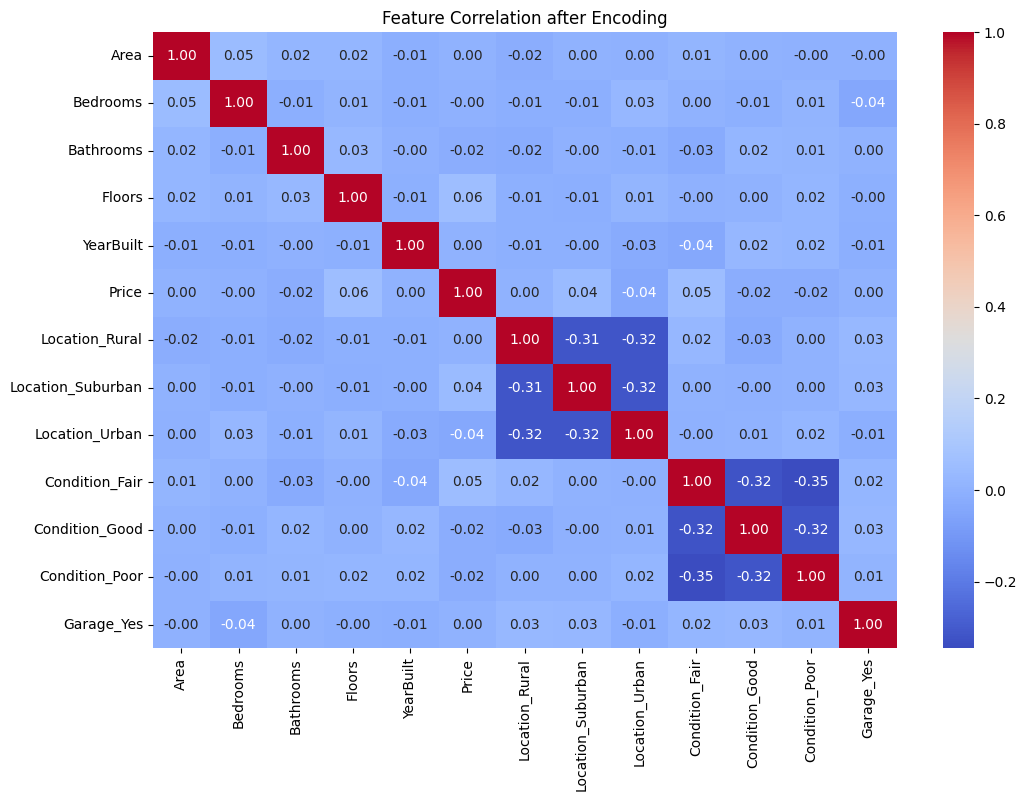

In [14]:
# Drop the 'Id' column as it's not useful for correlation
df_corr = df.drop('Id', axis=1)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_corr, columns=['Location', 'Condition', 'Garage'], drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation after Encoding")
plt.show()

**Feature Selection**

In [16]:
X = df[['Area','Bedrooms','Bathrooms']]
y = df['Price']

**Train Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Linear Regression Model**

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

**Train Random Forest Model**

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

**Evaluate Linear Regression**

In [20]:
mae_lr = mean_absolute_error(y_test, lr_predictions)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 243756.4797682511
Linear Regression RMSE: 280072.40125512274


**Evaluate Random Forest**

In [21]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 269693.2125363095
Random Forest RMSE: 322499.885915857


**Compare Models**

In [22]:
print("Model Comparison")

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

Model Comparison
Linear Regression RMSE: 280072.40125512274
Random Forest RMSE: 322499.885915857


**Prediction Visualization**

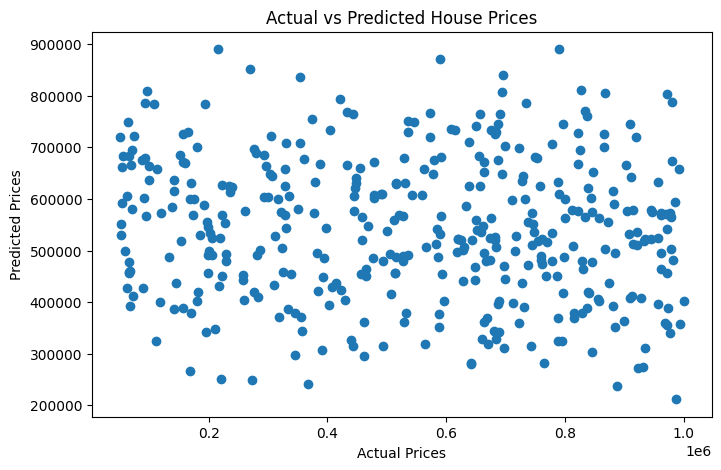

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

**Example Prediction**

In [24]:
sample_house = [[2000,3,2]]   # area, bedrooms, bathrooms

predicted_price = rf.predict(sample_house)

print("Predicted House Price:", predicted_price)

Predicted House Price: [543359.98]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
